In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

In [2]:
def plot_results(lambdas, test_accs):
    d = {'lambda': lambdas, 'test_acc': test_accs}
    df = pd.DataFrame(data=d)
    g = sns.scatterplot(x='lambda', y='test_acc', hue='test_acc', data=df, s=100)
    return g

def raw_str_to_arrays(raw_str):
    r = raw_str.split('\n')
    r = [x.split('     ') for x in r]
    print(r)
    r2 = [x[1] for x in r], [x[3] for x in r]
    return r2

def line(lambda_, color):
    #print([0, lambda_], [50, lambda_])
    #plt.plot([0, lambda_], [50, lambda_*50], linewidth=2)
    plt.axvline(x=lambda_, color=color, linewidth=2)

# Methodology


The mixup process, following the Facebook implementation, mixes input data X by linear interpolation with itself but randomly shuffled. We also save target predictions A and B of the normal X and shuffled X.

```
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
```

Then, we create the backpropagated loss by linear combination of two losses on target predictions A and B. The loss used is CrossEntropyLoss because it is fitting to a classification problem with C classes.

```
    pred = model(mixed_x)
    loss = lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)
```

The implementation difference between the Facebook implementation and this one is that Facebook samples lambdas from a Beta distribution of parameter alpha. In those trials instead we keep a constant lambda that we vary by grid search over several trained and tested models, such as lambdas in [0; 1] with 0.1 increments, or 0.25 increments.

# Setup

The model used for those experiments is ResNet18

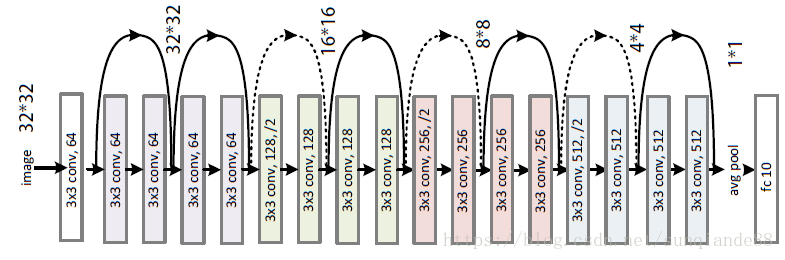

The datasets used for those experiments are classical machine learning datasets: CIFAR10 and CIFAR100.

The metric used to compare performance is the test accuracy:

$$ \text{Test accuracy} = \frac{\text{Number of correct classifications on test set}}{\text{Number of total classifications on test set}} = \frac{TP + TN}{TP + TN + FP + FN} $$

# Trials

### 100 epochs, 1000 batches of 100 images, CIFAR10, ResNet18

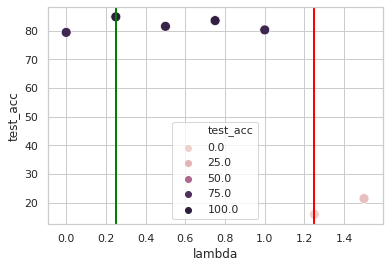

In [3]:
line(0.25, 'green')
line(1.25, 'red')
plot_results([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5], [79.35, 84.77, 81.46, 83.46, 80.21, 16.00, 21.51])

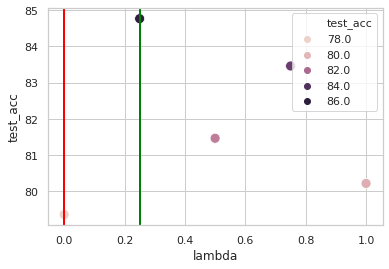

In [4]:
line(0.25, 'green')
line(0, 'red')
plot_results([0.0, 0.25, 0.5, 0.75, 1.0], [79.35, 84.77, 81.46, 83.46, 80.21])

<u>Observation</u>: The best test accuracy was yielded at $\lambda = 0.0$, the worst test accuracy was yielded at $\lambda = 0.25$. Average test accuracy of 79.78 without mixup was beaten using mixup for $\lambda \in \{0.25, 0.5, 0.75\} $.

### 30 epochs, 1000 batches of 50 images, CIFAR10, ResNet18

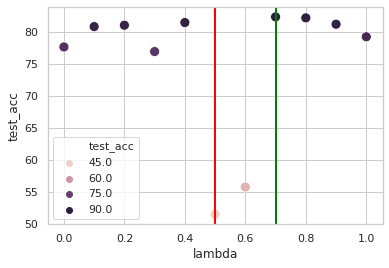

In [7]:
line(0.7, 'green')
line(0.5, 'red')
plot_results([0.1*x for x in range(11)], [77.63, 80.81, 81.02, 76.91, 81.44, 51.52, 55.78, 82.32, 82.17, 81.18, 79.22])

<u>Observation</u>: The best test accuracy was yielded at $\lambda = 0.7$, the worst test accuracy was yielded at $\lambda = 0.5$. Average test accuracy of 78.425 without mixup was beaten using mixup for $\lambda \in \{0.1, 0.2, 0.4, 0.7, 0.8, 0.9\} $.

### 50 epochs, 500 batches of 100 images, CIFAR10, ResNet18

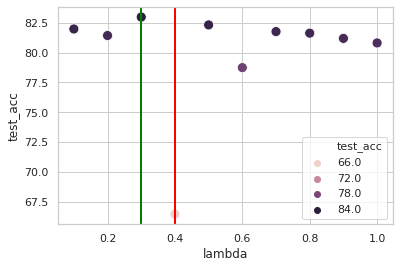

In [8]:
line(0.3, 'green')
line(0.4, 'red')
plot_results([0.1*x for x in range(1, 11)], [81.98, 81.43, 82.98, 66.46, 82.32, 78.74, 81.76, 81.63, 81.19, 80.81])

<u>Observation</u>: The best test accuracy was yielded at $\lambda = 0.3$, the worst test accuracy was yielded at $\lambda = 0.4$. Average test accuracy of 80.81 without mixup was beaten using mixup for $\lambda \in \{0.1, 0.2, 0.3, 0.4, 0.7, 0.8, 0.9\} $.

### 100 epochs, 500 batches of 100 images, CIFAR100, ResNet18

For this first attempt on CIFAR100 I took more time to train the model accounting for the 10-fold increase of the # of classes, I also halved the learning rate to 0.05.

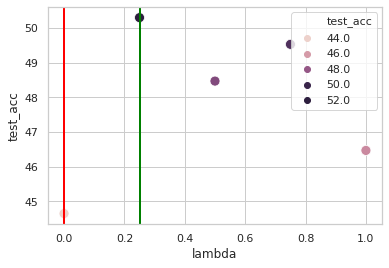

In [205]:
line(0.25, 'green')
line(0.0, 'red')
plot_results([0.25*x for x in range(5)], [44.65, 50.30, 48.47, 49.53, 46.47])

<u>Observation</u>: The test accuracy is lower due to the 10-fold increase of the # of classes. The lambda improvement is still clear.

Hovering around 45-50% test accuracy, I launched another trial doubling the training epochs. I keep the learning rate constant at 0.05, but 200 epochs could justify adjusting the learning rate midway.

The best test accuracy was yielded at $\lambda = 0.25$, the worst test accuracy was yielded at $\lambda = 0.0$. Average test accuracy of 45.56 without mixup was beaten using mixup for $\lambda \in \{0.25, 0.5, 0.75\} $.

### Aggregate results

Aggregating our results exposes the consistent yield we had throughout the experiments

In [206]:
exp1 = np.array([[0.0, 0.25, 0.5, 0.75, 1.0], [79.35, 84.77, 81.46, 83.46, 80.21]])
exp2 = np.array([[0.1*x for x in range(11)], [77.63, 80.81, 81.02, 76.91, 81.44, 51.52, 55.78, 82.32, 82.17, 81.18, 79.22]])
exp3 = np.array([[0.1*x for x in range(1, 11)], [81.98, 81.43, 82.98, 66.46, 82.32, 78.74, 81.76, 81.63, 81.19, 80.81]])
exp4 = np.array([[0.25*x for x in range(5)], [44.65, 50.30, 48.47, 49.53, 46.47]])
EXPS = [exp1, exp2, exp3, exp4]

In [207]:
normalize_exp = lambda exp: np.array([exp[0], (exp[1] - exp[1].mean()) / exp[1].std()])
NORMALIZED_EXPS = [normalize_exp(e) for e in EXPS]
agg_exp_lambdas = np.concatenate([exp[0] for exp in NORMALIZED_EXPS])
agg_exp_test_accs = np.concatenate([exp[1] for exp in NORMALIZED_EXPS])
agg_exp = np.array([agg_exp_lambdas, agg_exp_test_accs])

In [208]:
agg_df = pd.DataFrame(data=agg_exp.T, columns=["lambda", "test_acc_normalized"])

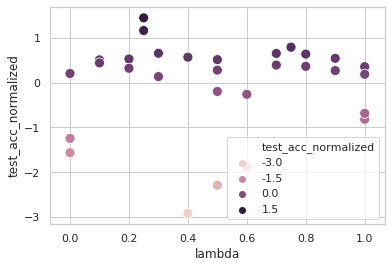

In [209]:

sns.scatterplot(data=agg_df, y="test_acc_normalized", x="lambda", hue="test_acc_normalized", s=100)

In [210]:
MEAN_NO_MIXUP = agg_df[(agg_df["lambda"] == 0) | (agg_df["lambda"] == 1)].mean()["test_acc_normalized"]
MEAN_NO_MIXUP

-0.5070690705104189

The mean test accuracy without using mixup, when normalized over a batch of trains on different lambdas, is -0.5. This means that mixup generally improves the test accuracy.

In [211]:
good_lambdas = agg_df[agg_df["test_acc_normalized"] >= MEAN_NO_MIXUP + 1]

To refine the "good" lambda value picks, we select only those that are above 1 std deviation over the mean test accuracy normalized without mixup.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fbfdaffdda0>,
      dtype=object)

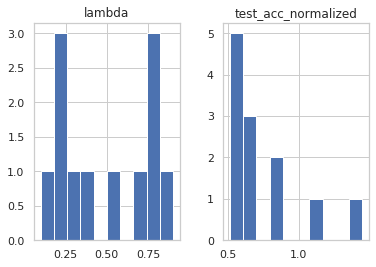

In [212]:
good_lambdas.hist()

<u>Observation</u>: We first find the expected symmetry around $\lambda=0.5$ for the good lambdas. We also find that the amount of performant lambdas peaks at $0.2 <= \lambda <=0.3$ or $0.7 <= \lambda <=0.8$, which seem to be the sweet spot for performance increase using mixup with a fixed lambda.

# Follow-up


 - Should we switch to trials on $0.0 <= \lambda <=0.5$ since the symmetry essentially means half the time spent on trials is just duplicate insights?
 - Current goal: many classes instead of 2 classes
 - Optional goal: make sense of weird behaviour using unconventional lamdas smaller than 0 or greater than 1